This section of the code is about giving the program access to the data needed as well performing data cleaning to make it ready to be analyzed.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kruskal
from statsmodels.tsa.stattools import ccf

cpi_file = 'CPIAUCSL.csv'
oil_file = 'WTISPLC.csv'
wheat_file = 'PWHEAMTUSDM.csv'
copper_file = 'PCOPPUSDM.csv'
ngas_file = 'DHHNGSP.csv'          
gold_file = 'PGOLD.csv'            

In [2]:
def read_fred_csv(filepath, value_col_name):
    df = pd.read_csv(filepath, index_col=0, parse_dates=True)
    df.columns = [value_col_name]
    df.index.name = 'Date'
    return df

In [5]:
cpi = read_fred_csv(cpi_file, 'CPI')
oil = read_fred_csv(oil_file, 'Oil')
wheat = read_fred_csv(wheat_file, 'Wheat')
copper = read_fred_csv(copper_file, 'Copper')
ngas = read_fred_csv(ngas_file, 'Natural_Gas')

In [7]:
gold = pd.read_csv(gold_file, encoding='utf-8-sig')   
gold = gold[['TIME_PERIOD', 'OBS_VALUE']].copy()

gold['Date'] = pd.to_datetime(gold['TIME_PERIOD'], format='%Y-M%m')

gold = gold[['Date', 'OBS_VALUE']].copy()
gold.columns = ['Date', 'Gold']
gold.set_index('Date', inplace=True)

The cells below join together the data contained in separate files into a singular database containing the inflation and commodity returns

In [9]:
dfs = [cpi, oil, wheat, copper, ngas, gold]
df = pd.concat(dfs, axis=1, join='inner')
df.sort_index(inplace=True)

In [11]:
commodities = ['Oil', 'Wheat', 'Copper', 'Natural_Gas', 'Gold']
for col in commodities:
    df[f'{col}_Return'] = df[col].pct_change() * 100

In [13]:
df['Inflation'] = df['CPI'].pct_change(periods=12) * 100

In [15]:
df = df.loc['2000-01-01':'2025-12-31'].copy()

In [17]:
low_thresh  = df['Inflation'].quantile(1/3)
high_thresh = df['Inflation'].quantile(2/3)

def inflation_regime(val):
    if val <= low_thresh:
        return 'Low'
    elif val <= high_thresh:
        return 'Moderate'
    else:
        return 'High'

df['Inflation_Regime'] = df['Inflation'].apply(inflation_regime)

In [19]:
df.to_csv('commodity_inflation_2000_2025.csv')
print('Final dataset saved. Shape:', df.shape)
print('Columns:', df.columns.tolist())

Final dataset saved. Shape: (300, 13)
Columns: ['CPI', 'Oil', 'Wheat', 'Copper', 'Natural_Gas', 'Gold', 'Oil_Return', 'Wheat_Return', 'Copper_Return', 'Natural_Gas_Return', 'Gold_Return', 'Inflation', 'Inflation_Regime']


In [21]:
print("First 5 rows:")
print(df.head())

print("\nLast 5 rows:")
print(df.tail())

print("\nInflation regime counts:")
print(df['Inflation_Regime'].value_counts())

print("\nMissing values per column:")
print(df.isnull().sum())

First 5 rows:
              CPI    Oil      Wheat       Copper  Natural_Gas        Gold  \
Date                                                                        
2000-01-01  169.3  27.18  93.622863  1843.850000         2.42  284.065625   
2000-02-01  170.0  29.35  98.166829  1807.025000         2.66  299.715000   
2000-03-01  171.0  29.89  96.396211  1739.800000         2.79  286.924000   
2000-04-01  170.9  25.74  94.431223  1681.907500         3.04  279.652632   
2000-05-01  171.2  28.78  99.112047  1785.097826         3.59  276.740909   

            Oil_Return  Wheat_Return  Copper_Return  Natural_Gas_Return  \
Date                                                                      
2000-01-01         NaN           NaN            NaN                 NaN   
2000-02-01    7.983812      4.853480      -1.997180            9.917355   
2000-03-01    1.839864     -1.803683      -3.720203            4.887218   
2000-04-01  -13.884242     -2.038449      -3.327538            8.960573

This section shows the data being being put together in order to show how returns contrast to inflation for each of the five major commodities. This is done through statistics being visualized.

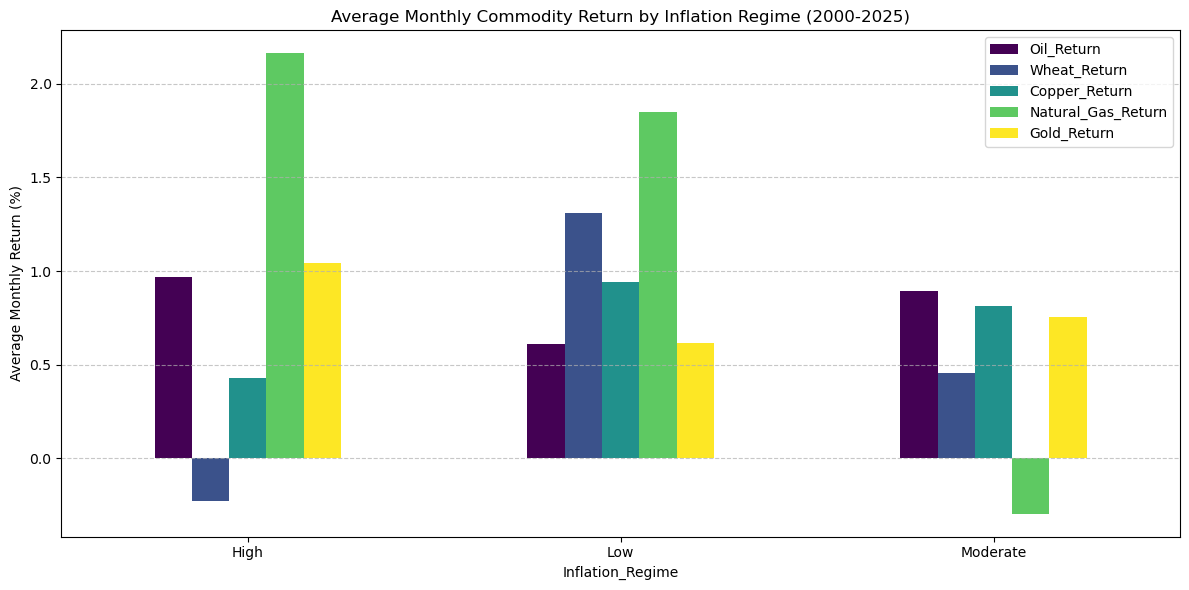

In [23]:
avg_returns = df.groupby('Inflation_Regime')[[f'{c}_Return' for c in commodities]].mean()

ax = avg_returns.plot(kind='bar', figsize=(12,6), rot=0, colormap='viridis')
ax.set_title('Average Monthly Commodity Return by Inflation Regime (2000-2025)')
ax.set_ylabel('Average Monthly Return (%)')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [25]:
print("Average Monthly Return by Inflation Regime (%):")
print(avg_returns.round(2).to_string())

Average Monthly Return by Inflation Regime (%):
                  Oil_Return  Wheat_Return  Copper_Return  Natural_Gas_Return  Gold_Return
Inflation_Regime                                                                          
High                    0.97         -0.23           0.43                2.16         1.04
Low                     0.61          1.31           0.94                1.85         0.62
Moderate                0.89          0.45           0.81               -0.29         0.75


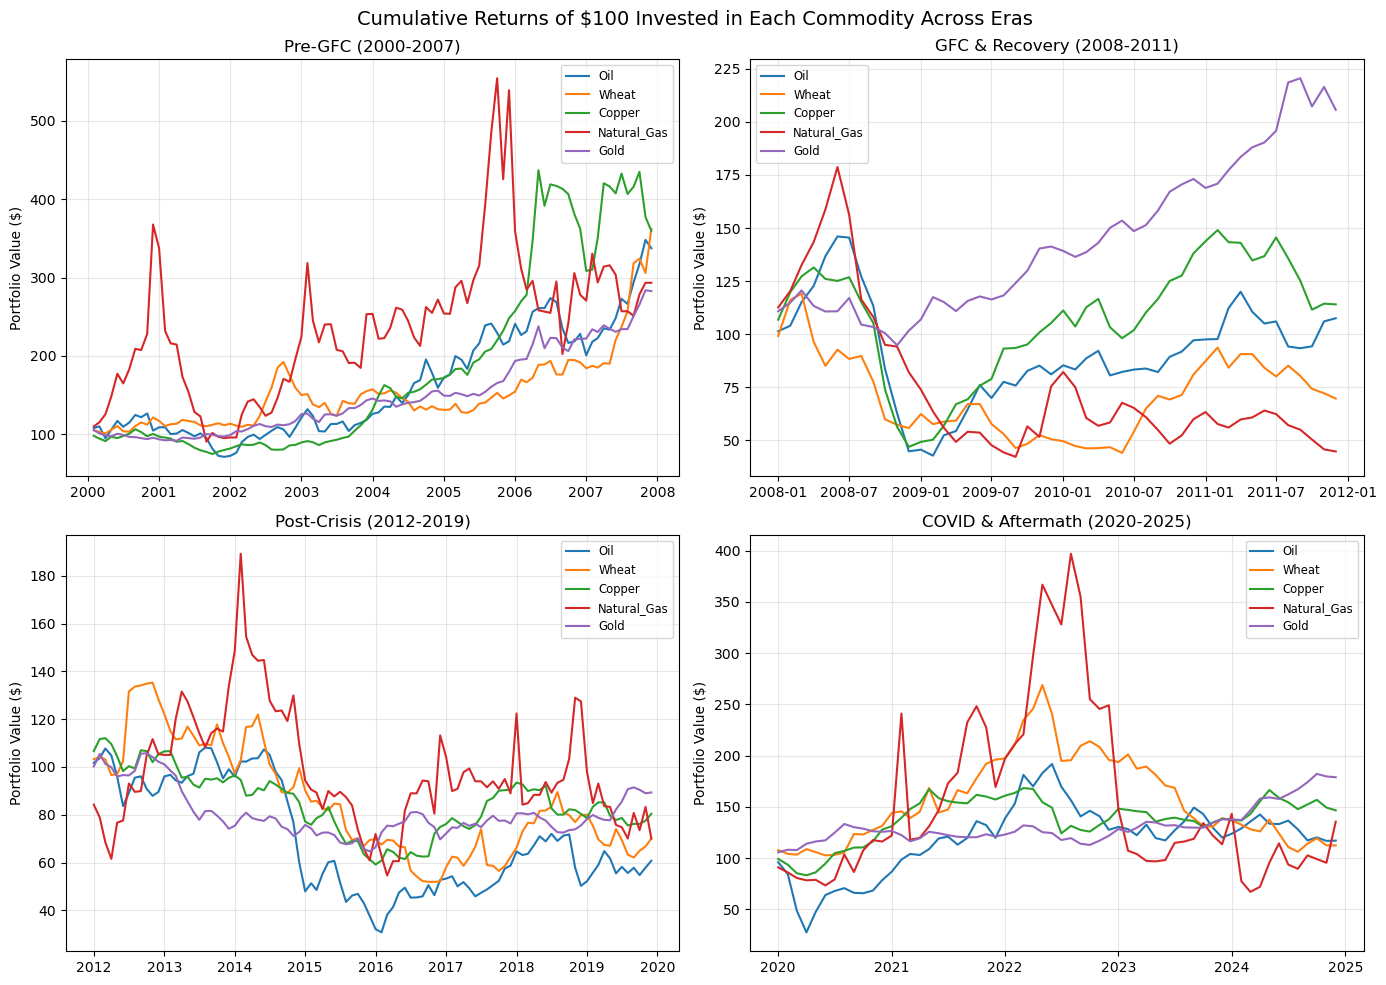

In [27]:
eras = {
    'Pre-GFC (2000-2007)': ('2000-01-01', '2007-12-31'),
    'GFC & Recovery (2008-2011)': ('2008-01-01', '2011-12-31'),
    'Post-Crisis (2012-2019)': ('2012-01-01', '2019-12-31'),
    'COVID & Aftermath (2020-2025)': ('2020-01-01', '2025-12-31')
}

fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes = axes.flatten()

for idx, (era, (start, end)) in enumerate(eras.items()):
    subset = df.loc[start:end]
    cumulative = (1 + subset[[f'{c}_Return' for c in commodities]] / 100).cumprod() * 100
    for col in commodities:
        axes[idx].plot(cumulative.index, cumulative[f'{col}_Return'], label=col)
    axes[idx].set_title(era)
    axes[idx].set_ylabel('Portfolio Value ($)')
    axes[idx].legend(fontsize='small')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Cumulative Returns of $100 Invested in Each Commodity Across Eras', fontsize=14)
plt.tight_layout()
plt.show()

In [29]:
print("\nFinal value of $100 invested in each era:")
for era, (start, end) in eras.items():
    subset = df.loc[start:end]
    cumulative = (1 + subset[[f'{c}_Return' for c in commodities]] / 100).cumprod() * 100
    final = cumulative.iloc[-1]
    print(f"\n{era}:")
    for col in commodities:
        print(f"  {col}: ${final[f'{col}_Return']:.2f}")


Final value of $100 invested in each era:

Pre-GFC (2000-2007):
  Oil: $337.49
  Wheat: $362.33
  Copper: $359.61
  Natural_Gas: $293.39
  Gold: $282.75

GFC & Recovery (2008-2011):
  Oil: $107.46
  Wheat: $69.59
  Copper: $114.00
  Natural_Gas: $44.65
  Gold: $205.71

Post-Crisis (2012-2019):
  Oil: $60.75
  Wheat: $70.01
  Copper: $80.40
  Natural_Gas: $70.03
  Gold: $89.33

COVID & Aftermath (2020-2025):
  Oil: $117.10
  Wheat: $112.43
  Copper: $146.62
  Natural_Gas: $135.59
  Gold: $178.90


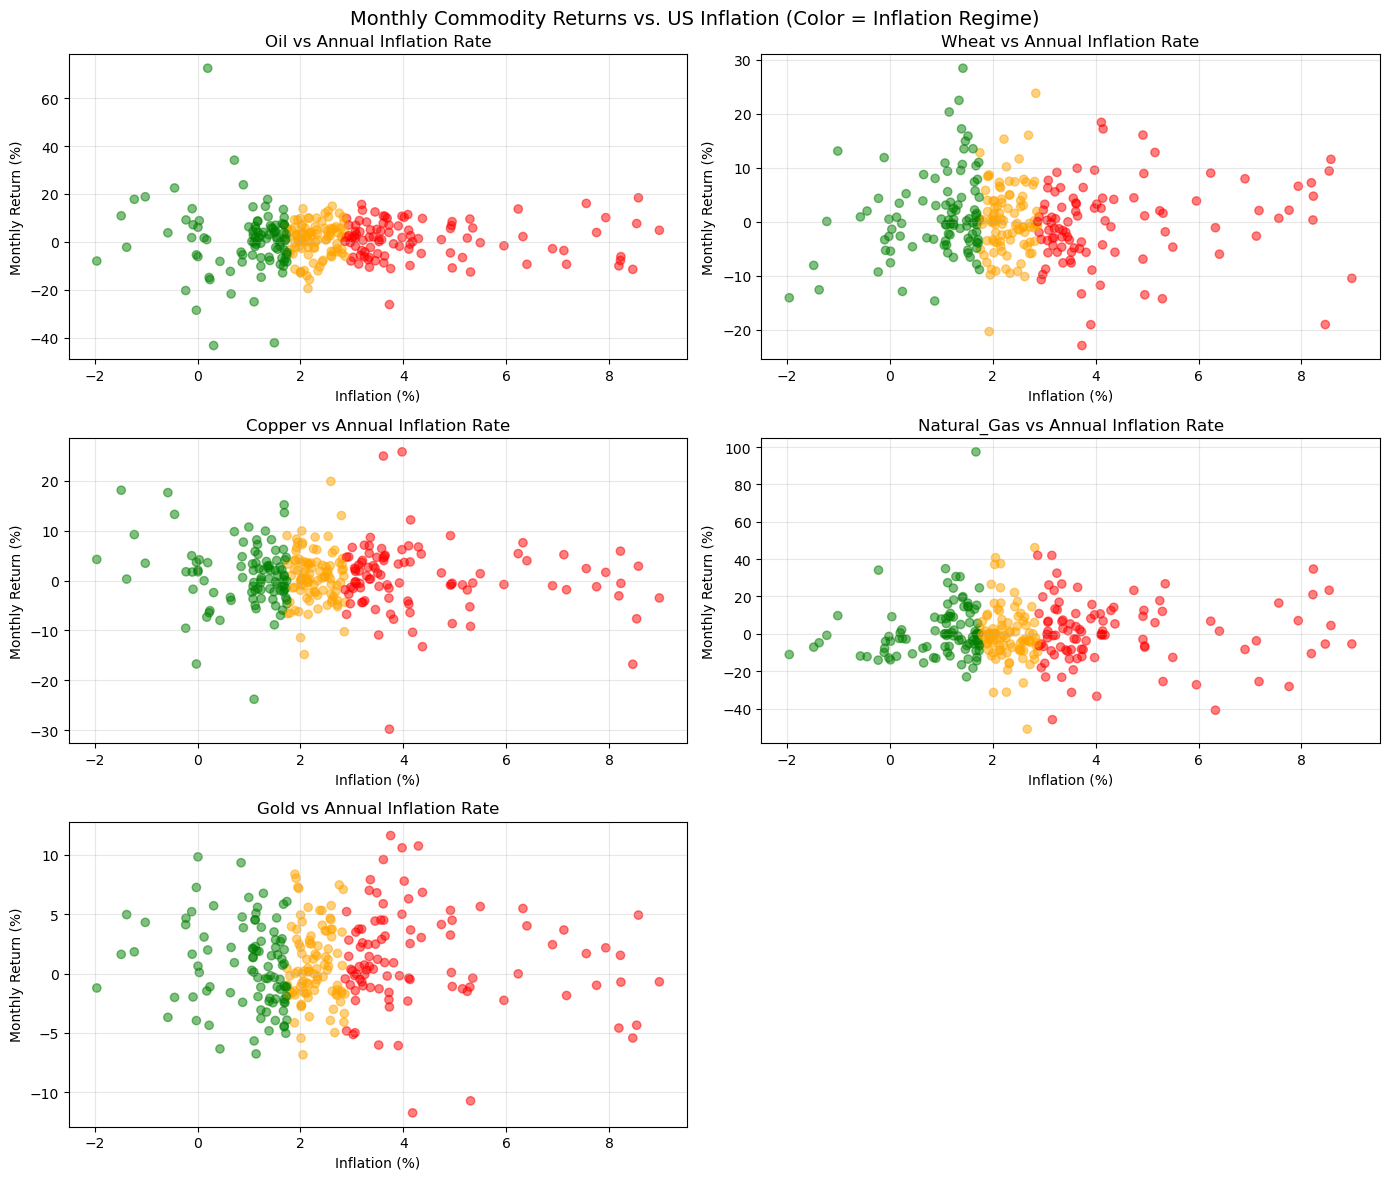

In [31]:
fig, axs = plt.subplots(3, 2, figsize=(14,12))
axs = axs.flatten()

for i, col in enumerate(commodities):
    ax = axs[i]
    colors = df['Inflation_Regime'].map({'Low': 'green', 'Moderate': 'orange', 'High': 'red'})
    ax.scatter(df['Inflation'], df[f'{col}_Return'], alpha=0.5, c=colors)
    ax.set_title(f'{col} vs Annual Inflation Rate')
    ax.set_xlabel('Inflation (%)')
    ax.set_ylabel('Monthly Return (%)')
    ax.grid(True, alpha=0.3)

axs[5].axis('off')
plt.suptitle('Monthly Commodity Returns vs. US Inflation (Color = Inflation Regime)', fontsize=14)
plt.tight_layout()
plt.show()

These cells use the Kruskal-Wallis test to check whether the null hypothesis that the distributions are identical can be rejected. The case for rejection of the null hypothesis is for a commodity to have a p-value greater than 0.05. 

In [35]:
results_kw = []
for col in commodities:
    groups = [df[df['Inflation_Regime'] == r][f'{col}_Return'].dropna() for r in ['Low','Moderate','High']]
    stat, p = kruskal(*groups)
    results_kw.append({'Commodity': col, 'Kruskal-Stat': stat, 'p-value': p})

kw_df = pd.DataFrame(results_kw)
print("Kruskal-Wallis Test Results (Null: distributions are identical):")
print(kw_df.round(4).to_string())

Kruskal-Wallis Test Results (Null: distributions are identical):
     Commodity  Kruskal-Stat  p-value
0          Oil        0.2170   0.8972
1        Wheat        0.6062   0.7385
2       Copper        0.1745   0.9165
3  Natural_Gas        2.3179   0.3138
4         Gold        1.0604   0.5885


Lag is computed through the cross‑correlation between annual inflation and the monthly return of each each commodity at lags from 12 before to 12 months after. A peak at positive lag means the commodity tends to move before inflation changes; a peak at negative lag means it reacts afterwards.

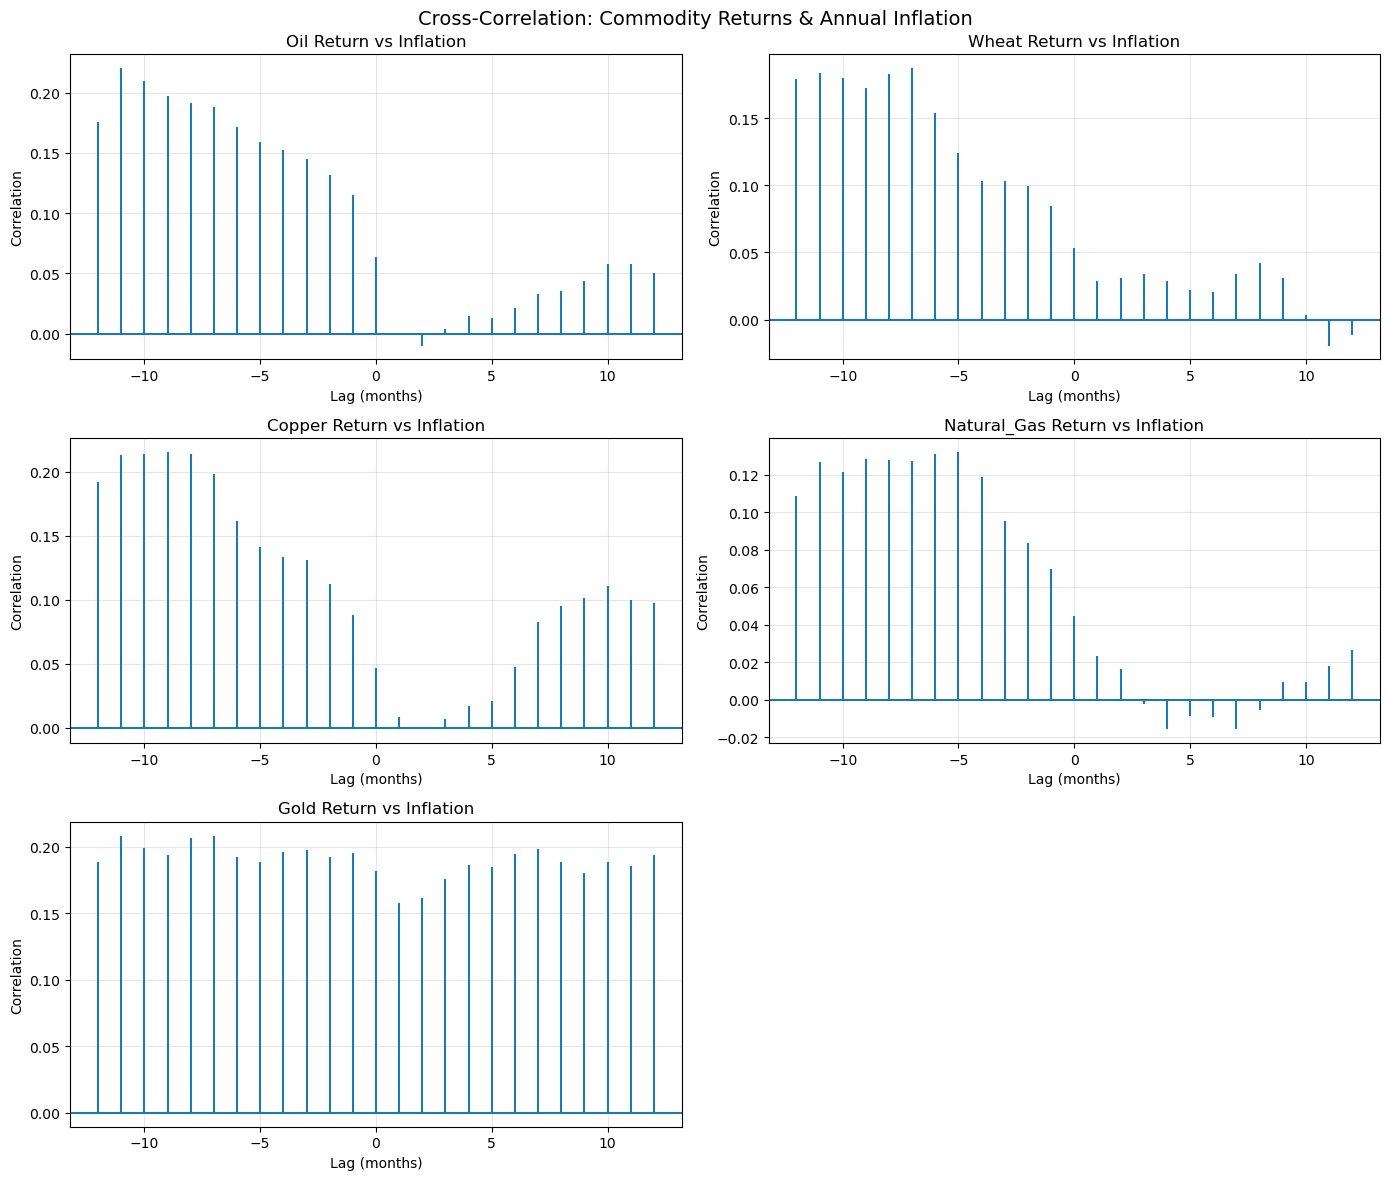

In [37]:
lags = range(-12, 13)
fig, axs = plt.subplots(3, 2, figsize=(14,12))
axs = axs.flatten()

for i, col in enumerate(commodities):
    valid = df[[f'{col}_Return', 'Inflation']].dropna()
    ccf_vals = ccf(valid[f'{col}_Return'], valid['Inflation'], adjusted=False)[:25]  
    ax = axs[i]
    ax.xcorr(valid[f'{col}_Return'], valid['Inflation'], maxlags=12, usevlines=True, normed=True)
    ax.set_title(f'{col} Return vs Inflation')
    ax.set_xlabel('Lag (months)')
    ax.set_ylabel('Correlation')
    ax.grid(True, alpha=0.3)

axs[5].axis('off')
plt.suptitle('Cross‑Correlation: Commodity Returns & Annual Inflation', fontsize=14)
plt.tight_layout()
plt.show()

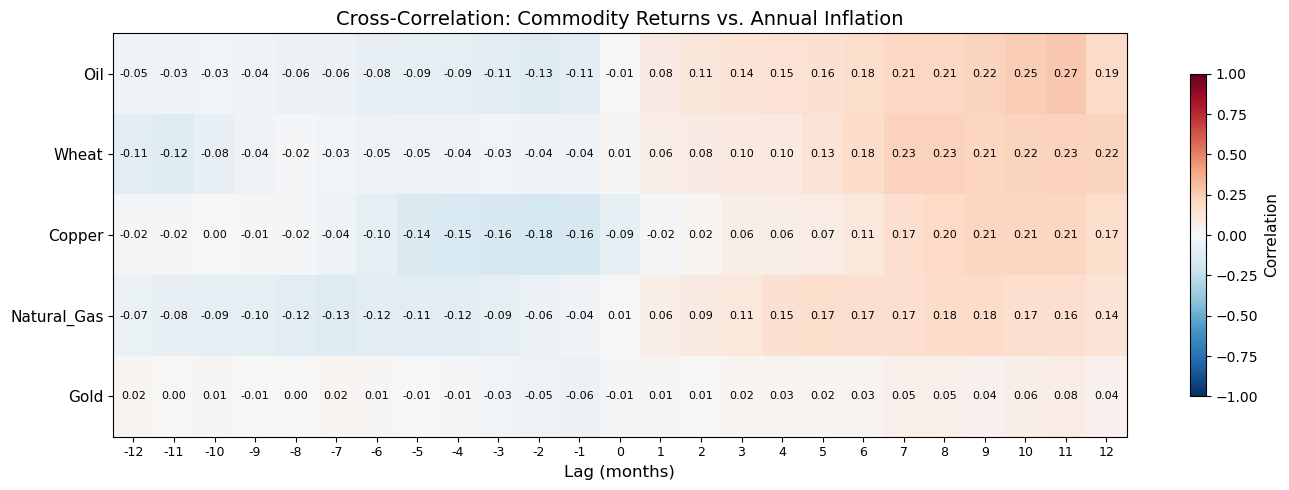

In [39]:
lags = list(range(-12, 13))
corr_matrix = []

for col in commodities:
    valid = df[[f'{col}_Return', 'Inflation']].dropna()
    row = []
    for lag in lags:
        row.append(valid[f'{col}_Return'].corr(valid['Inflation'].shift(-lag)))
    corr_matrix.append(row)

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(corr_matrix, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)

ax.set_xticks(range(len(lags)))
ax.set_xticklabels(lags, fontsize=9)
ax.set_yticks(range(len(commodities)))
ax.set_yticklabels(commodities, fontsize=11)
ax.set_xlabel('Lag (months)', fontsize=12)
ax.set_title('Cross‑Correlation: Commodity Returns vs. Annual Inflation', fontsize=14)

for i in range(len(commodities)):
    for j in range(len(lags)):
        val = corr_matrix[i][j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', 
                fontsize=8, color='black' if abs(val) < 0.7 else 'white')

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Correlation', fontsize=11)
plt.tight_layout()
plt.show()